# Hackathon IndabaX Cameroon 2026
## Modélisation IA — Résilience Climatique et Sanitaire
**ML Masters**

Ce notebook présente le travail de notre équipe Data & ML qui consistait à la préparation des données et la modélisation IA. Pour répondre  à la problématique du changement climatique et de la santé publique au Cameroun, nous avons modélisé **7 indicateurs clés** répartis en 3 axes majeurs :

### Axe 1 : Le Cycle de l'Eau
1. **Déficit en eau cumulé** : Mesure du manque d'eau sur 30 jours (Évapotranspiration vs Précipitations).
2. **Sécheresse agricole** : Catégorisation de l'impact du déficit sur les cultures (de "Excédent" à "Sécheresse sévère").
3. **Risque d'inondation** : Indice composite [0-10] évaluant le risque de crues soudaines.

### Axe 2 : Les Risques Thermiques
4. **Chaleur extrême** : Indice composite [0-10] du stress thermique lié au rayonnement solaire.
5. **Chaleur ressentie humide (Heat Index)** : Formule de Rothfusz évaluant le danger mortel de la combinaison Chaleur + Humidité (très pertinent pour la région côtière de Douala).

### Axe 3 : La Qualité de l'Air (Santé Respiratoire)
6. **Valeur du proxy PM2.5** : Estimation de la concentration en particules fines (µg/m³) basée sur les vents, la saison sèche et l'absence de pluie.
7. **Qualité de l'air (AQI)** : Traduction du PM2.5 en norme internationale de santé publique compréhensible par les citoyens.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import time
import os
warnings.filterwarnings('ignore')
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from sklearn.model_selection import TimeSeriesSplit, train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
import xgboost as xgb
import lightgbm as lgb
import shap

sns.set_theme(style='whitegrid', palette='muted')
SEED    = 42
N_SPLITS = 5

os.makedirs('models', exist_ok=True)
os.makedirs('plots',  exist_ok=True)

print('Imports')


Imports


In [2]:
df = pd.read_excel('data/Dataset_complet_Meteo.xlsx')

COLS_TEXTE = ['time', 'sunrise', 'sunset', 'city', 'region']

df['time'] = pd.to_datetime(df['time'], errors='coerce')
for col in ['sunrise', 'sunset']:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

for col in df.columns:
    if col not in COLS_TEXTE:
        df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.sort_values(['city', 'time']).reset_index(drop=True)

print(f'Dataset chargé : {df.shape[0]:,} observations × {df.shape[1]} variables')
print(f'   Période  : {df["time"].min().date()} → {df["time"].max().date()}')
print(f'   Villes   : {df["city"].nunique()} | Régions : {df["region"].nunique()}')
df.head(3)


Dataset chargé : 87,240 observations × 26 variables
   Période  : 2020-01-01 → 2025-12-20
   Villes   : 40 | Régions : 10


,id,time,weather_code,temperature_2m_max,temperature_2m_min,temperature_2m_mean,apparent_temperature_max,apparent_temperature_min,apparent_temperature_mean,sunrise,...,precipitation_hours,wind_speed_10m_max,wind_gusts_10m_max,wind_direction_10m_dominant,shortwave_radiation_sum,et0_fao_evapotranspiration,city,region,latitude,longitude
0,2182,2020-01-01,3,31.4,NaN,NaN,33.6,NaN,24.0,2020-01-01 06:13:00,...,0.0,NaN,NaN,338,21.57,4.64,Abong-Mbang,Est,3.98,13.17
1,2183,2020-01-02,3,30.2,16.0,NaN,31.2,15.0,NaN,2020-01-02 06:14:00,...,0.0,NaN,NaN,344,NaN,4.55,Abong-Mbang,Est,3.98,13.17
2,2184,2020-01-03,3,NaN,NaN,NaN,30.2,NaN,NaN,2020-01-03 06:14:00,...,0.0,NaN,NaN,38,20.66,NaN,Abong-Mbang,Est,3.98,13.17


---
## 2.  Construction des 7 Indicateurs

> Tous les indicateurs sont des **proxies construits** à partir des variables météorologiques disponibles.

### Axe 1 — Le Cycle de l'Eau
Nous utilisons les formules de la FAO (Organisation des Nations Unies pour l'alimentation et l'agriculture) pour calculer le bilan hydrique.
1. **Déficit en eau cumulé :** `ET0 (Evapotranspiration) - Précipitations` cumulé sur 30 jours glissants (temps de cycle racinaire moyen).
2. **Sécheresse agricole :** Catégorisation du déficit pour la prise de décision.
3. **Risque Inondation :** Combinaison pondérée (Pluie 40%, Pluie cumulée 30%, Heures de pluie 20%, Rafales 10%) normalisée sur une échelle de 0 à 10.


### Axe 2 — Les Risques Thermiques
Le réchauffement climatique n'augmente pas seulement la température brute, mais sa dangerosité combinée.
4. **Chaleur Extrême :** Indice composite intégrant le rayonnement solaire direct et la température ressentie.
5. **Chaleur ressentie humide (Heat Index) :** Utilisation de la *formule de Rothfusz (NOAA)*. L'humidité empêche la transpiration de s'évaporer, rendant des températures de 32°C potentiellement mortelles au Cameroun.

### Axe 3 — Qualité de l'Air (Santé Respiratoire)
L'absence de capteurs directs de PM2.5 nous impose la création d'un proxy robuste.
*   **Proxy PM2.5 (µg/m³) :** Poussé par la sécheresse, la stagnation des vents et le rayonnement. La pluie joue le rôle de "lessivage" naturel.
*   **Qualité de l'Air (AQI) :** Conversion du proxy PM2.5 en norme internationale (Échelle de 0 à 500) pour alerter les populations.


**Pourquoi un Proxy ?**
Le dataset officiel du hackathon fournit des données climatiques riches, mais ne contient pas de capteurs directs de PM2.5 (particules fines). Notre mission étant l'aide à la décision sanitaire, nous avons modélisé un **indicateur indirect (Proxy)** mathématique.

**La Logique Scientifique :**
La pollution de l'air au Cameroun  obéit à des règles climatiques strictes :
6. **Facteurs Aggravants :** La stagnation de l'air (absence de vent `+10`), la saison sèche (`+5`), une température et un rayonnement solaire élevés favorisent la concentration des polluants.
7. **Facteur Purifiant :** Les précipitations agissent comme un lessivage naturel de l'atmosphère (baisse drastique de la pollution).
Notre formule combine ces éléments pour simuler une concentration en µg/m³.


In [3]:
# AXE 1 — CYCLE DE L'EAU
# Réf : FAO Irrigation & Drainage Paper 56 (Allen et al., 1998)

# 1. Déficit en eau cumulé (30 jours glissants)
df['water_deficit_daily'] = (
    df['et0_fao_evapotranspiration'].fillna(0) - df['precipitation_sum'].fillna(0)
)
df['deficit_eau_cumule'] = (
    df.groupby('city')['water_deficit_daily']
    .transform(lambda x: x.rolling(30, min_periods=7).sum())
)

# 2. Sécheresse agricole (catégorisation)
def categorie_secheresse(val):
    if pd.isna(val):  return 'Inconnu'
    if val <= -6:     return 'Sécheresse sévère'
    if val <= -3:     return 'Stress modéré'
    if val < 0:       return 'Stress léger'
    if val < 2:       return 'Équilibré'
    return 'Excédent'

df['secheresse_agricole'] = df['deficit_eau_cumule'].apply(categorie_secheresse)

# 3. Risque d'inondation [0–10]
score_inondation_brut = (
    0.40 * df['precipitation_sum'].fillna(0) +
    0.30 * df['rain_sum'].fillna(0) +
    0.20 * df['precipitation_hours'].fillna(0) +
    0.10 * df['wind_gusts_10m_max'].fillna(0)
)
scaler_flood = MinMaxScaler(feature_range=(0, 10))
df['risque_inondation'] = scaler_flood.fit_transform(
    score_inondation_brut.values.reshape(-1, 1)
).flatten()

def categorie_inondation(val):
    if val <= 2: return 'Risque faible'
    if val <= 4: return 'Risque modéré'
    if val <= 6: return 'Risque élevé'
    return 'Alerte inondation'

df['cat_inondation'] = df['risque_inondation'].apply(categorie_inondation)

print(' Axe 1 — Cycle de l\'eau :', df[['deficit_eau_cumule','risque_inondation']].describe().round(2).to_dict())


 Axe 1 — Cycle de l'eau : {'deficit_eau_cumule': {'count': 87000.0, 'mean': 65.88, 'std': 105.2, 'min': -1507.22, '25%': 44.68, '50%': 75.58, '75%': 108.42, 'max': 271.37}, 'risque_inondation': {'count': 87240.0, 'mean': 0.2, 'std': 0.3, 'min': 0.0, '25%': 0.07, '50%': 0.18, '75%': 0.24, 'max': 10.0}}


In [4]:
# AXE 2 — RISQUES THERMIQUES

# 4. Chaleur extrême [0–10] (indice composite rayonnement + température)
score_chaleur_brut = (
    0.40 * df['apparent_temperature_max'].fillna(df['apparent_temperature_max'].median()) +
    0.25 * df['temperature_2m_max'].fillna(df['temperature_2m_max'].median()) +
    0.20 * (df['sunshine_duration'].fillna(0) / 3600) +
    0.15 * (df['shortwave_radiation_sum'].fillna(0) / 10)
)
scaler_heat_ext = MinMaxScaler(feature_range=(0, 10))
df['chaleur_extreme'] = scaler_heat_ext.fit_transform(
    score_chaleur_brut.values.reshape(-1, 1)
).flatten()

def categorie_chaleur(val):
    if val <= 2: return 'Confort thermique'
    if val <= 4: return 'Chaleur modérée'
    if val <= 6: return 'Chaleur élevée'
    if val <= 8: return 'Vague de chaleur'
    return 'Danger / alerte rouge'

df['cat_chaleur'] = df['chaleur_extreme'].apply(categorie_chaleur)

# 5. Heat Index — Formule de Rothfusz (NOAA)
# Réf : Rothfusz, 1990, NWS Technical Attachment SR 90-23

df['humidity_est'] = (
    100 - 5 * (df['temperature_2m_mean'] - df['apparent_temperature_mean'])
).clip(0, 100).fillna(70)

T = df['temperature_2m_mean'].fillna(df['temperature_2m_mean'].median())
R = df['humidity_est']

df['heat_index'] = (
    -42.379
    + 2.04901523  * T
    + 10.14333127 * R
    - 0.22475541  * T * R
    - 0.00683783  * T**2
    - 0.05481717  * R**2
    + 0.00122874  * T**2 * R
    + 0.00085282  * T * R**2
    - 0.00000199  * T**2 * R**2
).clip(lower=0)

print('Axe 2 — Risques thermiques :', df[['chaleur_extreme','heat_index']].describe().round(2).to_dict())


Axe 2 — Risques thermiques : {'chaleur_extreme': {'count': 87240.0, 'mean': 5.57, 'std': 0.89, 'min': 0.0, '25%': 5.1, '50%': 5.57, '75%': 5.87, 'max': 10.0}, 'heat_index': {'count': 87240.0, 'mean': 203.11, 'std': 13.55, 'min': 111.2, '25%': 204.81, '50%': 204.81, '75%': 204.81, 'max': 264.74}}


In [5]:
# AXE 3 — QUALITÉ DE L'AIR (PM2.5 PROXY)
# Facteurs aggravants : sécheresse, stagnation, chaleur, rayonnement
# Facteur purifiant  : précipitations (lessivage atmosphérique)
# Réf : WHO Air Quality Guidelines 2021 + Liousse et al. (Afrique sub.)

df['month']          = df['time'].dt.month
df['is_dry_season']  = df['month'].isin([11, 12, 1, 2, 3]).astype(int)
df['is_no_wind']     = (df['wind_speed_10m_max'] < 5).astype(int)
df['is_no_rain']     = (df['precipitation_sum'] < 0.1).astype(int)
df['sunshine_ratio'] = df['sunshine_duration'] / (df['daylight_duration'] + 1e-6)

# 6. Proxy PM2.5 (µg/m³)
df['pm25_proxy'] = (
    0.40 * df['temperature_2m_mean'].fillna(df['temperature_2m_mean'].median())
    + 0.30 * df['shortwave_radiation_sum'].fillna(0)
    + 0.20 * df['et0_fao_evapotranspiration'].fillna(0)
    + 10.0 * df['is_no_wind']
    + 6.0  * df['is_no_rain']
    + 5.0  * df['is_dry_season']
    + 0.10 * df['sunshine_ratio'].fillna(0)
).clip(lower=8.0, upper=150.0)

# 7. Indice AQI & catégorie qualité de l'air
AQI_TRANCHES = [
    (0,    12.0,  0,  50,  'Bon'),
    (12.1, 35.4, 51, 100,  'Modéré'),
    (35.5, 55.4, 101, 150, 'Sensible'),
    (55.5, 150.4, 151, 200,'Malsain'),
    (150.5,250.4, 201, 300,'Très mauvais'),
    (250.5,500.0, 301, 500,'Dangereux'),
]

def pm25_to_aqi(c):
    for c_bas, c_haut, aqi_bas, aqi_haut, label in AQI_TRANCHES:
        if c_bas <= c <= c_haut:
            aqi_val = round((aqi_haut - aqi_bas) / (c_haut - c_bas) * (c - c_bas) + aqi_bas)
            return pd.Series([aqi_val, label])
    return pd.Series([500, 'Dangereux']) if c > 0 else pd.Series([0, 'Bon'])

df[['indice_aqi', 'qualite_air_categorie']] = df['pm25_proxy'].apply(pm25_to_aqi)

print('Axe 3 — Qualité de l\'air :', df[['pm25_proxy','indice_aqi']].describe().round(2).to_dict())


Axe 3 — Qualité de l'air : {'pm25_proxy': {'count': 87240.0, 'mean': 19.18, 'std': 5.99, 'min': 8.0, '25%': 14.97, '50%': 17.11, '75%': 22.67, 'max': 35.52}, 'indice_aqi': {'count': 87240.0, 'mean': 65.81, 'std': 17.59, 'min': 33.0, '25%': 57.0, '50%': 62.0, '75%': 73.0, 'max': 500.0}}


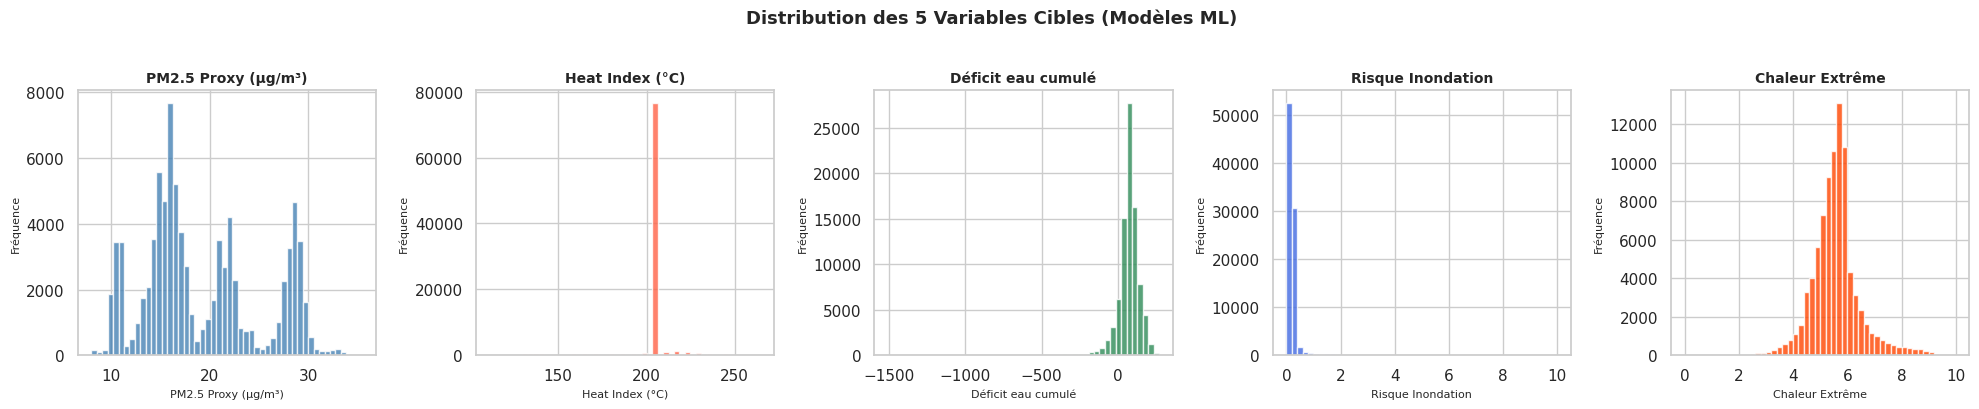

In [6]:
# Visualisation des distributions des 5 cibles continues
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

targets_viz = [
    ('pm25_proxy',        'PM2.5 Proxy (µg/m³)', 'steelblue'),
    ('heat_index',        'Heat Index (°C)',       'tomato'),
    ('deficit_eau_cumule','Déficit eau cumulé',    'seagreen'),
    ('risque_inondation', 'Risque Inondation',     'royalblue'),
    ('chaleur_extreme',   'Chaleur Extrême',       'orangered'),
]

for ax, (col, label, color) in zip(axes, targets_viz):
    ax.hist(df[col].dropna(), bins=50, color=color, alpha=0.8, edgecolor='white')
    ax.set_title(label, fontweight='bold', fontsize=10)
    ax.set_xlabel(label, fontsize=8)
    ax.set_ylabel('Fréquence', fontsize=8)

plt.suptitle('Distribution des 5 Variables Cibles (Modèles ML)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/distributions_cibles.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 3. Feature Engineering

> Feature set riche incluant variables météo brutes, dérivées, lags temporels,
> statistiques glissantes et encodage géographique.


In [7]:
# Variables temporelles
df['year']        = df['time'].dt.year
df['quarter']     = df['time'].dt.quarter
df['day_of_year'] = df['time'].dt.dayofyear
df['month_sin']   = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos']   = np.cos(2 * np.pi * df['month'] / 12)
df['dow_sin']     = np.sin(2 * np.pi * df['time'].dt.dayofweek / 7)
df['dow_cos']     = np.cos(2 * np.pi * df['time'].dt.dayofweek / 7)

# Variables dérivées
df['temp_amplitude'] = df['temperature_2m_max'] - df['temperature_2m_min']

# Variables de lag (1, 2, 3, 7, 14, 30 jours)
for lag in [1, 2, 3, 7, 14, 30]:
    df[f'temp_lag{lag}'] = df.groupby('city')['temperature_2m_mean'].shift(lag)
    df[f'wind_lag{lag}'] = df.groupby('city')['wind_speed_10m_max'].shift(lag)
    df[f'rain_lag{lag}'] = df.groupby('city')['precipitation_sum'].shift(lag)

# Rolling statistics
for window in [3, 7, 14, 30]:
    df[f'temp_roll{window}_mean'] = df.groupby('city')['temperature_2m_mean'].transform(
        lambda x: x.rolling(window, min_periods=1).mean())
    df[f'temp_roll{window}_std'] = df.groupby('city')['temperature_2m_mean'].transform(
        lambda x: x.rolling(window, min_periods=1).std().fillna(0))
    df[f'rain_roll{window}_sum'] = df.groupby('city')['precipitation_sum'].transform(
        lambda x: x.rolling(window, min_periods=1).sum())

# Encodage géographique
df['region_enc'] = df['region'].astype('category').cat.codes
df['city_enc']   = df['city'].astype('category').cat.codes

print(f'Feature Engineering terminé — {df.shape[1]} colonnes au total')

# Feature set commun pour tous les modèles
FEATURES = [
    # Météo brute
    'temperature_2m_mean', 'temperature_2m_max', 'temperature_2m_min',
    'apparent_temperature_mean', 'apparent_temperature_max',
    'precipitation_sum', 'rain_sum', 'precipitation_hours',
    'wind_speed_10m_max', 'wind_gusts_10m_max',
    'shortwave_radiation_sum', 'et0_fao_evapotranspiration',
    'sunshine_duration', 'daylight_duration',
    # Dérivées
    'temp_amplitude', 'sunshine_ratio', 'humidity_est',
    'is_no_wind', 'is_no_rain', 'is_dry_season',
    # Temporelles
    'month_sin', 'month_cos', 'dow_sin', 'dow_cos',
    'day_of_year', 'quarter', 'year',
    # Lags
    'temp_lag1', 'temp_lag2', 'temp_lag3', 'temp_lag7', 'temp_lag14', 'temp_lag30',
    'wind_lag1', 'wind_lag7', 'wind_lag14',
    'rain_lag1', 'rain_lag7', 'rain_lag14',
    # Rolling
    'temp_roll3_mean', 'temp_roll7_mean', 'temp_roll14_mean', 'temp_roll30_mean',
    'temp_roll7_std',  'temp_roll30_std',
    'rain_roll3_sum',  'rain_roll7_sum',  'rain_roll14_sum', 'rain_roll30_sum',
    # Géo
    'latitude', 'longitude', 'region_enc', 'city_enc'
]

FEATURES = [f for f in FEATURES if f in df.columns]
print(f' {len(FEATURES)} features sélectionnées pour les modèles ML')


Feature Engineering terminé — 83 colonnes au total
 53 features sélectionnées pour les modèles ML


In [8]:
# Préparation des données pour une cible donnée
def prepare_data(target_col):
    df_m = df[FEATURES + [target_col]].copy()
    for col in FEATURES:
        if df_m[col].isna().any():
            df_m[col] = df_m[col].fillna(df_m[col].median())
    df_m = df_m.dropna(subset=[target_col])
    return df_m[FEATURES].values, df_m[target_col].values


# Calcul des métriques
def compute_metrics(y_true, y_pred):
    return {
        'R²'  : round(r2_score(y_true, y_pred), 4),
        'MAE' : round(mean_absolute_error(y_true, y_pred), 4),
        'RMSE': round(np.sqrt(mean_squared_error(y_true, y_pred)), 4),
    }


# Courbes de loss (MAE) train vs val
def plot_loss_curves(train_losses, val_losses, model_name, ax):
    folds = list(range(1, len(train_losses) + 1))
    ax.plot(folds, train_losses, marker='o', lw=2, color='steelblue', label='Train MAE')
    ax.plot(folds, val_losses,   marker='s', lw=2, color='tomato',    label='Val MAE', linestyle='--')
    ax.fill_between(folds, train_losses, val_losses, alpha=0.08, color='gray')
    ax.set_title(model_name, fontweight='bold', fontsize=9)
    ax.set_xlabel('Fold'); ax.set_ylabel('MAE')
    ax.set_xticks(folds); ax.legend(fontsize=8); ax.grid(True, linestyle='--', alpha=0.4)


# Pipeline principal : CV ranking
def run_cv_ranking(target_name, models_dict, color='steelblue'):

    print(f'\n{"*" * 76}')
    print(f'  RANKING — Cible : {target_name.upper()}')
    print(f'{"*" * 76}')

    X, y = prepare_data(target_name)
    tscv  = TimeSeriesSplit(n_splits=N_SPLITS)
    n_mod = len(models_dict)

    fig, axes = plt.subplots(1, n_mod, figsize=(5 * n_mod, 4), sharey=False)
    if n_mod == 1: axes = [axes]

    results = []
    trained_models = {}

    for ax, (model_name, model) in zip(axes, models_dict.items()):
        train_maes, val_maes, fold_metrics = [], [], []

        for fold, (tr_idx, val_idx) in enumerate(tscv.split(X), 1):
            X_tr, X_val = X[tr_idx], X[val_idx]
            y_tr, y_val = y[tr_idx], y[val_idx]

            if 'MLP' in model_name:
                scaler = StandardScaler()
                X_tr  = scaler.fit_transform(X_tr)
                X_val = scaler.transform(X_val)

            model.fit(X_tr, y_tr)
            train_maes.append(mean_absolute_error(y_tr,  model.predict(X_tr)))
            val_maes.append(  mean_absolute_error(y_val, model.predict(X_val)))
            fold_metrics.append(compute_metrics(y_val, model.predict(X_val)))

        plot_loss_curves(train_maes, val_maes, model_name, ax)

        mean_r2   = np.mean([m['R²']   for m in fold_metrics])
        mean_mae  = np.mean([m['MAE']  for m in fold_metrics])
        mean_rmse = np.mean([m['RMSE'] for m in fold_metrics])
        std_mae   = np.std( [m['MAE']  for m in fold_metrics])

        results.append({'Modèle': model_name, 'R² (moy)': round(mean_r2, 4),
                        'MAE (moy)': round(mean_mae, 4), 'MAE (std)': round(std_mae, 4),
                        'RMSE (moy)': round(mean_rmse, 4)})
        trained_models[model_name] = model
        print(f'   {model_name:<26} R²={mean_r2:.4f}  MAE={mean_mae:.4f} ± {std_mae:.4f}')

    plt.suptitle(f'Courbes Train/Val Loss — {target_name}', fontsize=12, fontweight='bold', y=1.03)
    plt.tight_layout()
    plt.savefig(f'plots/loss_{target_name}.png', dpi=130, bbox_inches='tight')
    plt.show()

    ranking = (pd.DataFrame(results).sort_values('R² (moy)', ascending=False).reset_index(drop=True))
    ranking.index += 1; ranking.index.name = 'Rang'
    print(f'\n  Ranking final — {target_name}')
    print(ranking.to_string())

    # Réentraîner le meilleur modèle
    best_name  = ranking.iloc[0]['Modèle']
    best_model = trained_models[best_name]
    if 'MLP' in best_name:
        scaler_full = StandardScaler()
        best_model.fit(scaler_full.fit_transform(X), y)
    else:
        best_model.fit(X, y)

    print(f' Meilleur modèle : {best_name} — réentraîné')
    return ranking, best_name, best_model


# Feature importance plot
def plot_feature_importance(model, model_name, target_name, color='steelblue', top_n=15):
    if not hasattr(model, 'feature_importances_'):
        print(f'  [info] {model_name} ne supporte pas feature_importances_')
        return
    importances = pd.Series(model.feature_importances_, index=FEATURES)
    top = importances.sort_values(ascending=False).head(top_n)
    plt.figure(figsize=(10, 5))
    top.sort_values().plot(kind='barh', color=color, alpha=0.85)
    plt.title(f'Top {top_n} Features — {target_name} ({model_name})', fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'plots/importance_{target_name}.png', dpi=130, bbox_inches='tight')
    plt.show()

print('Fonctions utilitaires définies')


Fonctions utilitaires définies


---
## 5. Ranking — PM2.5 Proxy

> **Objectif :** Prédire la concentration estimée en particules fines (µg/m³)
> à partir des données météorologiques. Indicateur central de la qualité de l'air.



****************************************************************************
  RANKING — Cible : PM25_PROXY
****************************************************************************
   Random Forest              R²=0.9895  MAE=0.1994 ± 0.1685
   XGBoost                    R²=0.9927  MAE=0.1611 ± 0.1495
   LightGBM                   R²=0.9932  MAE=0.1562 ± 0.1376
   MLP                        R²=0.8261  MAE=1.0902 ± 0.9142


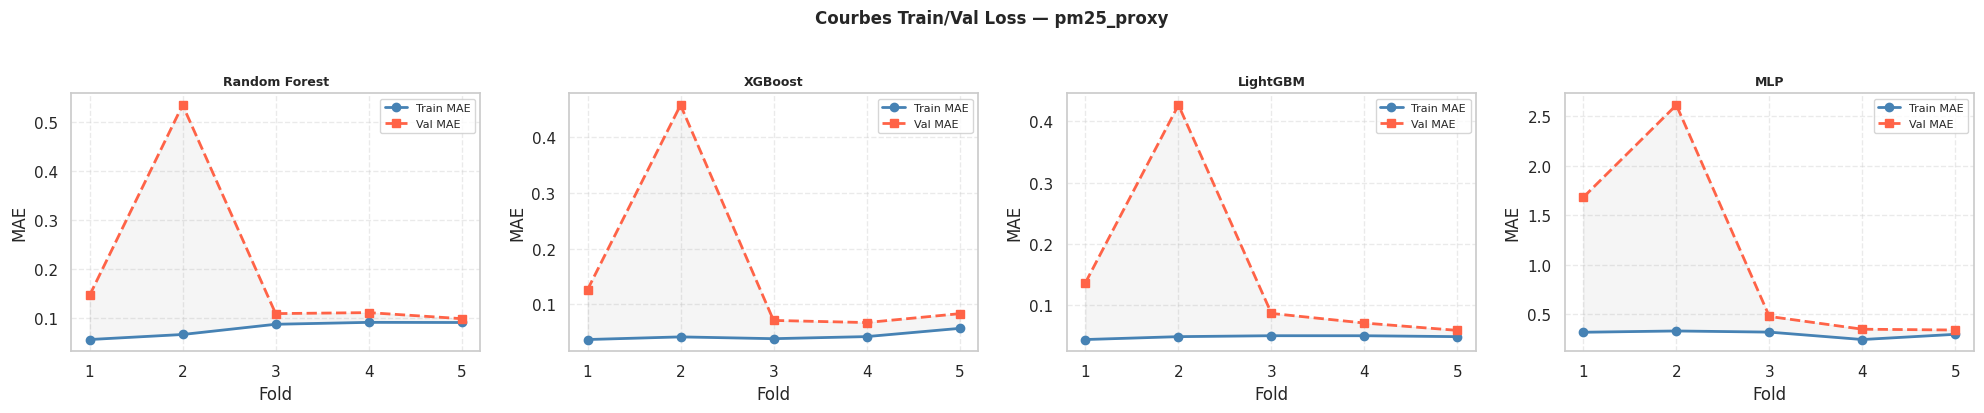


  Ranking final — pm25_proxy
             Modèle  R² (moy)  MAE (moy)  MAE (std)  RMSE (moy)
Rang                                                           
1          LightGBM    0.9932     0.1562     0.1376      0.4056
2           XGBoost    0.9927     0.1611     0.1495      0.4277
3     Random Forest    0.9895     0.1994     0.1685      0.4983
4               MLP    0.8261     1.0902     0.9142      1.9143
 Meilleur modèle : LightGBM — réentraîné


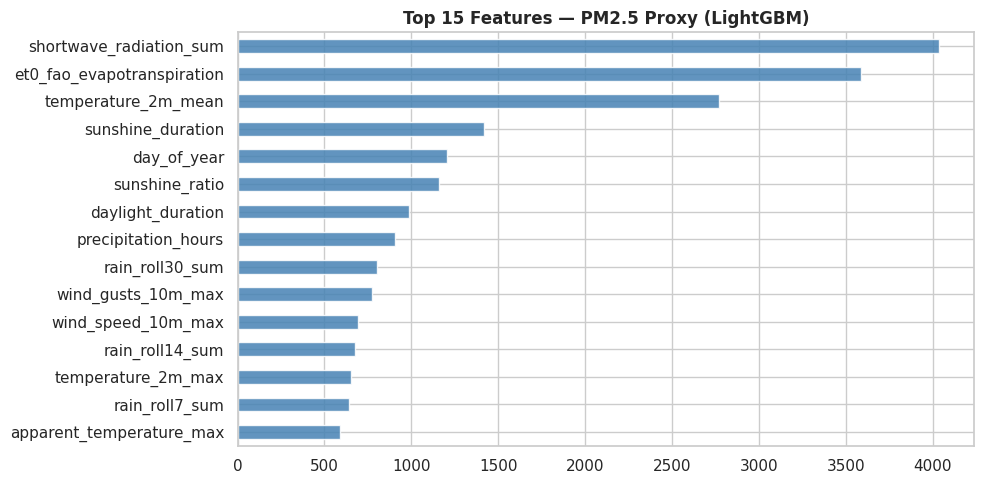

In [9]:
models_pm25 = {
    'Random Forest': RandomForestRegressor(
        n_estimators=200, max_depth=10, n_jobs=-1, random_state=SEED),
    'XGBoost': xgb.XGBRegressor(
        n_estimators=500, max_depth=7, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        tree_method='hist', random_state=SEED, verbosity=0),
    'LightGBM': lgb.LGBMRegressor(
        n_estimators=500, num_leaves=63, learning_rate=0.05,
        feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=5,
        min_child_samples=20, random_state=SEED, verbosity=-1),
    'MLP': MLPRegressor(
        hidden_layer_sizes=(256, 128, 64), activation='relu', solver='adam',
        learning_rate_init=1e-3, max_iter=300,
        early_stopping=True, validation_fraction=0.1, random_state=SEED),
}

ranking_pm25, best_name_pm25, best_model_pm25 = run_cv_ranking('pm25_proxy', models_pm25, color='steelblue')
plot_feature_importance(best_model_pm25, best_name_pm25, 'PM2.5 Proxy', color='steelblue')


---
## 6. Ranking — Heat Index (Chaleur Ressentie Humide)

> **Objectif :** Prédire l'indice de chaleur humide (formule de Rothfusz).  
> Indicateur de risque sanitaire lié aux vagues de chaleur, particulièrement
> pertinent pour les zones côtières comme Douala.



****************************************************************************
  RANKING — Cible : HEAT_INDEX
****************************************************************************
   Random Forest              R²=0.9580  MAE=0.6485 ± 1.2653
   XGBoost                    R²=0.9523  MAE=0.7353 ± 1.3583
   LightGBM                   R²=0.9580  MAE=0.7045 ± 1.2866
   MLP                        R²=-0.9166  MAE=4.9169 ± 5.4532


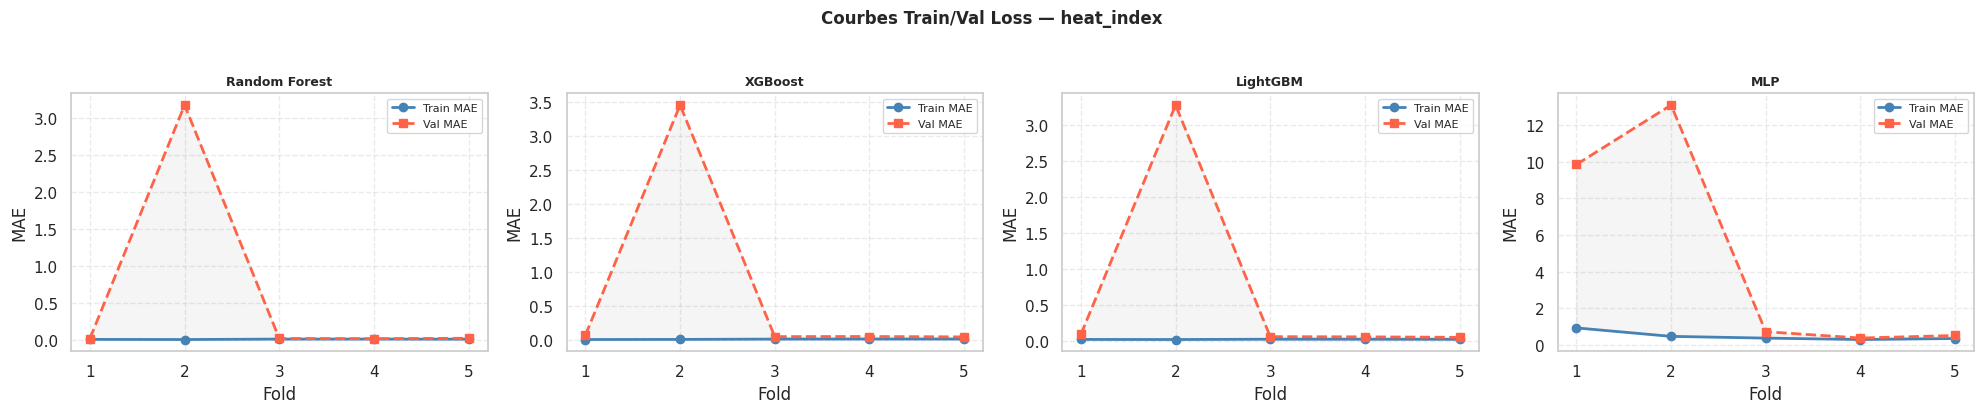


  Ranking final — heat_index
             Modèle  R² (moy)  MAE (moy)  MAE (std)  RMSE (moy)
Rang                                                           
1     Random Forest    0.9580     0.6485     1.2653      2.1471
2          LightGBM    0.9580     0.7045     1.2866      2.2065
3           XGBoost    0.9523     0.7353     1.3583      2.3301
4               MLP   -0.9166     4.9169     5.4532      8.8004
 Meilleur modèle : Random Forest — réentraîné


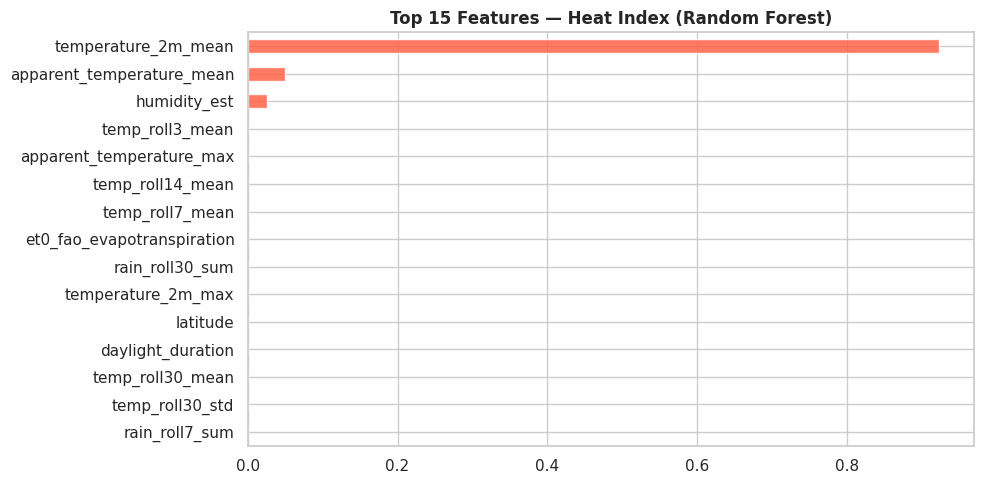

In [10]:
models_heat = {
    'Random Forest': RandomForestRegressor(
        n_estimators=200, max_depth=10, n_jobs=-1, random_state=SEED),
    'XGBoost': xgb.XGBRegressor(
        n_estimators=500, max_depth=7, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        tree_method='hist', random_state=SEED, verbosity=0),
    'LightGBM': lgb.LGBMRegressor(
        n_estimators=500, num_leaves=63, learning_rate=0.05,
        feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=5,
        min_child_samples=20, random_state=SEED, verbosity=-1),
    'MLP': MLPRegressor(
        hidden_layer_sizes=(256, 128, 64), activation='relu', solver='adam',
        learning_rate_init=1e-3, max_iter=300,
        early_stopping=True, validation_fraction=0.1, random_state=SEED),
}

ranking_heat, best_name_heat, best_model_heat = run_cv_ranking('heat_index', models_heat, color='tomato')
plot_feature_importance(best_model_heat, best_name_heat, 'Heat Index', color='tomato')


---
## 7. Ranking — Stress Hydrique (Déficit Eau Cumulé)

> **Objectif :** Prédire l'accumulation du déficit hydrique sur 30 jours.  
> Indicateur de risque de sécheresse agricole (manioc, maïs).



****************************************************************************
  RANKING — Cible : DEFICIT_EAU_CUMULE
****************************************************************************
   Random Forest              R²=0.7955  MAE=20.6891 ± 11.6979
   XGBoost                    R²=0.7910  MAE=21.4173 ± 12.9015
   LightGBM                   R²=0.8065  MAE=20.3001 ± 11.8268
   MLP                        R²=0.8392  MAE=22.0116 ± 9.6983


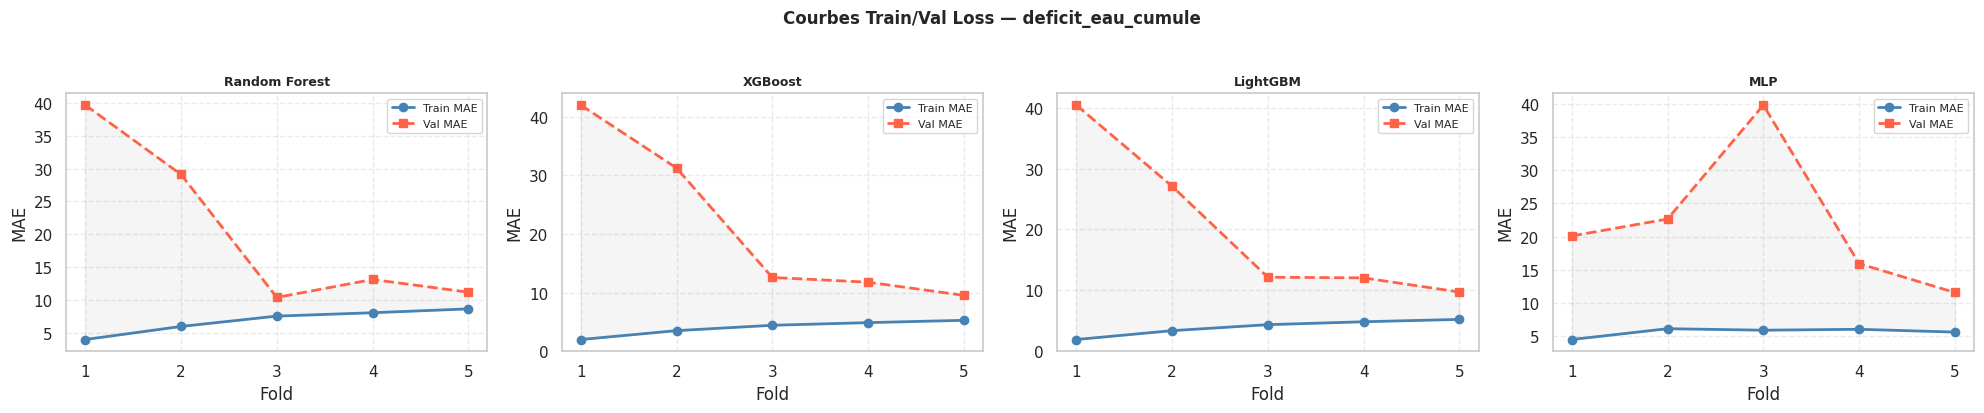


  Ranking final — deficit_eau_cumule
             Modèle  R² (moy)  MAE (moy)  MAE (std)  RMSE (moy)
Rang                                                           
1               MLP    0.8392    22.0116     9.6983     31.7148
2          LightGBM    0.8065    20.3001    11.8268     46.8506
3     Random Forest    0.7955    20.6891    11.6979     47.3887
4           XGBoost    0.7910    21.4173    12.9015     48.2923
 Meilleur modèle : MLP — réentraîné
  [info] MLP ne supporte pas feature_importances_


In [11]:
models_water = {
    'Random Forest': RandomForestRegressor(
        n_estimators=200, max_depth=10, n_jobs=-1, random_state=SEED),
    'XGBoost': xgb.XGBRegressor(
        n_estimators=500, max_depth=7, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        tree_method='hist', random_state=SEED, verbosity=0),
    'LightGBM': lgb.LGBMRegressor(
        n_estimators=500, num_leaves=63, learning_rate=0.05,
        feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=5,
        min_child_samples=20, random_state=SEED, verbosity=-1),
    'MLP': MLPRegressor(
        hidden_layer_sizes=(256, 128, 64), activation='relu', solver='adam',
        learning_rate_init=1e-3, max_iter=300,
        early_stopping=True, validation_fraction=0.1, random_state=SEED),
}

ranking_water, best_name_water, best_model_water = run_cv_ranking('deficit_eau_cumule', models_water, color='seagreen')
plot_feature_importance(best_model_water, best_name_water, 'Stress Hydrique', color='seagreen')


---
## 8. Ranking — Risque d'Inondation

> **Objectif :** Prédire l'indice composite de risque d'inondation [0–10].



****************************************************************************
  RANKING — Cible : RISQUE_INONDATION
****************************************************************************
   Random Forest              R²=0.9768  MAE=0.0139 ± 0.0051
   XGBoost                    R²=0.9801  MAE=0.0149 ± 0.0065
   LightGBM                   R²=0.9708  MAE=0.0154 ± 0.0072
   MLP                        R²=0.9210  MAE=0.0236 ± 0.0111


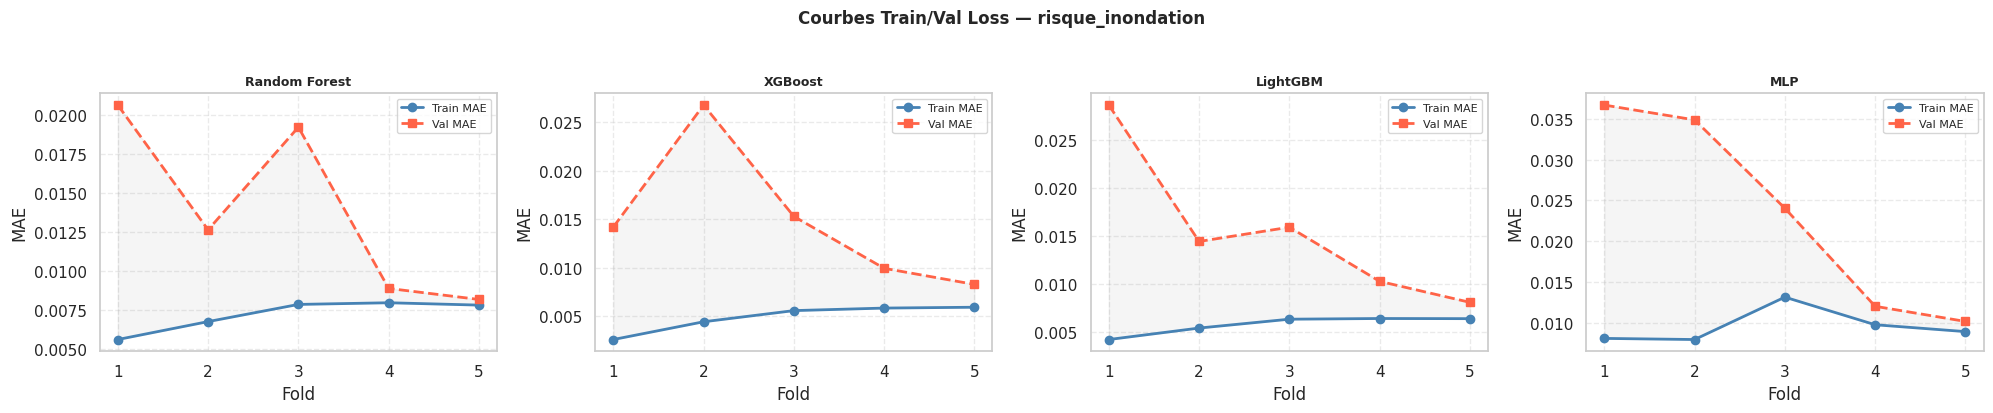


  Ranking final — risque_inondation
             Modèle  R² (moy)  MAE (moy)  MAE (std)  RMSE (moy)
Rang                                                           
1           XGBoost    0.9801     0.0149     0.0065      0.0407
2     Random Forest    0.9768     0.0139     0.0051      0.0474
3          LightGBM    0.9708     0.0154     0.0072      0.0527
4               MLP    0.9210     0.0236     0.0111      0.0673
 Meilleur modèle : XGBoost — réentraîné


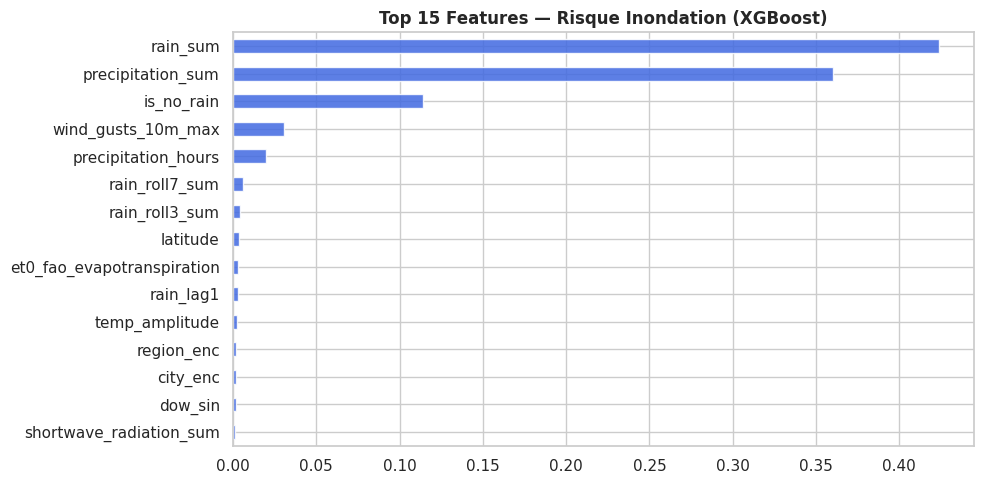

In [12]:
models_flood = {
    'Random Forest': RandomForestRegressor(
        n_estimators=200, max_depth=10, n_jobs=-1, random_state=SEED),
    'XGBoost': xgb.XGBRegressor(
        n_estimators=500, max_depth=7, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        tree_method='hist', random_state=SEED, verbosity=0),
    'LightGBM': lgb.LGBMRegressor(
        n_estimators=500, num_leaves=63, learning_rate=0.05,
        feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=5,
        min_child_samples=20, random_state=SEED, verbosity=-1),
    'MLP': MLPRegressor(
        hidden_layer_sizes=(256, 128, 64), activation='relu', solver='adam',
        learning_rate_init=1e-3, max_iter=300,
        early_stopping=True, validation_fraction=0.1, random_state=SEED),
}

ranking_flood, best_name_flood, best_model_flood = run_cv_ranking('risque_inondation', models_flood, color='royalblue')
plot_feature_importance(best_model_flood, best_name_flood, 'Risque Inondation', color='royalblue')


---
## 9. Ranking — Chaleur Extrême

> **Objectif :** Prédire l'indice composite de chaleur extrême [0–10]
> (rayonnement solaire + température ressentie).



****************************************************************************
  RANKING — Cible : CHALEUR_EXTREME
****************************************************************************
   Random Forest              R²=0.9760  MAE=0.0778 ± 0.0403
   XGBoost                    R²=0.9863  MAE=0.0359 ± 0.0375
   LightGBM                   R²=0.9874  MAE=0.0350 ± 0.0351
   MLP                        R²=0.7829  MAE=0.1355 ± 0.1255


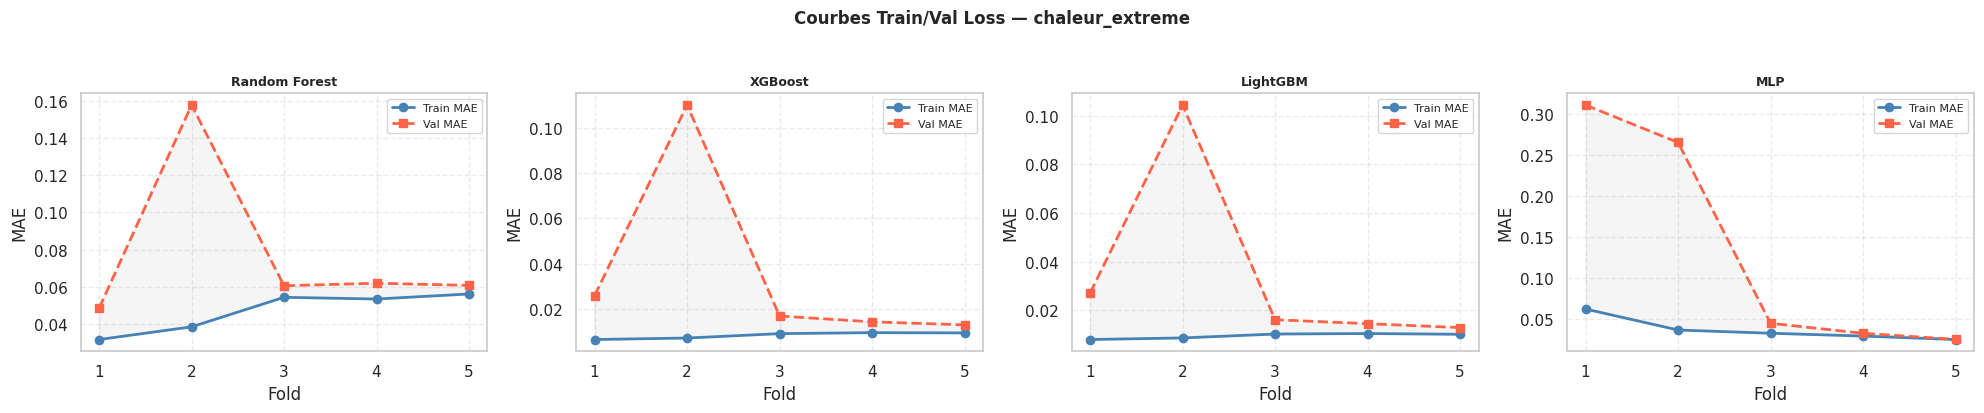


  Ranking final — chaleur_extreme
             Modèle  R² (moy)  MAE (moy)  MAE (std)  RMSE (moy)
Rang                                                           
1          LightGBM    0.9874     0.0350     0.0351      0.0824
2           XGBoost    0.9863     0.0359     0.0375      0.0858
3     Random Forest    0.9760     0.0778     0.0403      0.1334
4               MLP    0.7829     0.1355     0.1255      0.2579
 Meilleur modèle : LightGBM — réentraîné


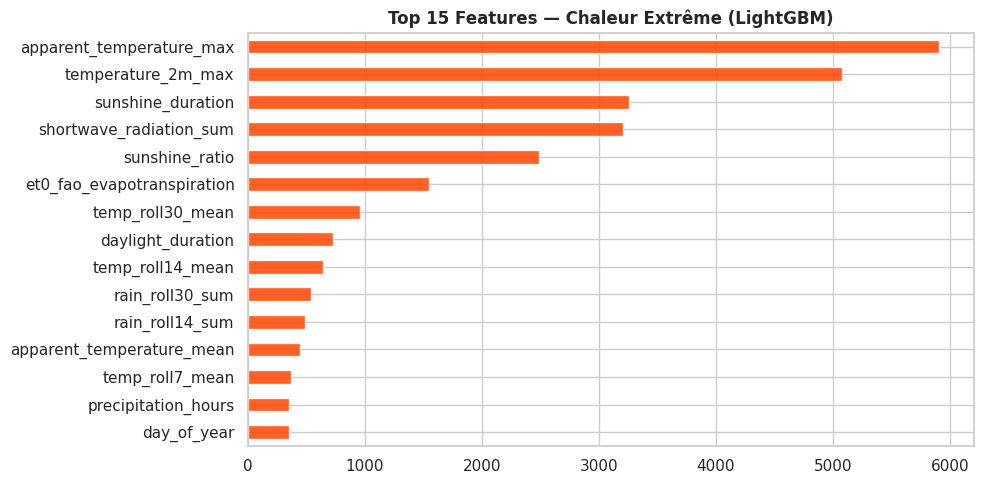

In [13]:
models_heat_ext = {
    'Random Forest': RandomForestRegressor(
        n_estimators=200, max_depth=10, n_jobs=-1, random_state=SEED),
    'XGBoost': xgb.XGBRegressor(
        n_estimators=500, max_depth=7, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        tree_method='hist', random_state=SEED, verbosity=0),
    'LightGBM': lgb.LGBMRegressor(
        n_estimators=500, num_leaves=63, learning_rate=0.05,
        feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=5,
        min_child_samples=20, random_state=SEED, verbosity=-1),
    'MLP': MLPRegressor(
        hidden_layer_sizes=(256, 128, 64), activation='relu', solver='adam',
        learning_rate_init=1e-3, max_iter=300,
        early_stopping=True, validation_fraction=0.1, random_state=SEED),
}

ranking_heat_ext, best_name_heat_ext, best_model_heat_ext = run_cv_ranking(
    'chaleur_extreme', models_heat_ext, color='orangered')
plot_feature_importance(best_model_heat_ext, best_name_heat_ext, 'Chaleur Extrême', color='orangered')


---
## 10.  Modèle Ensemble Final — PM2.5 (LightGBM + XGBoost)

> **Stratégie :** VotingRegressor combinant LightGBM et XGBoost (les deux meilleurs
> dans le ranking PM2.5). Maximise la robustesse pour le déploiement sur l'API FastAPI.


Entraînement du modèle Ensemble (LightGBM + XGBoost) — PM2.5...

 Performances Ensemble (test) :
   R²   = 0.9988
   RMSE = 0.21 µg/m³
   MAE  = 0.06 µg/m³


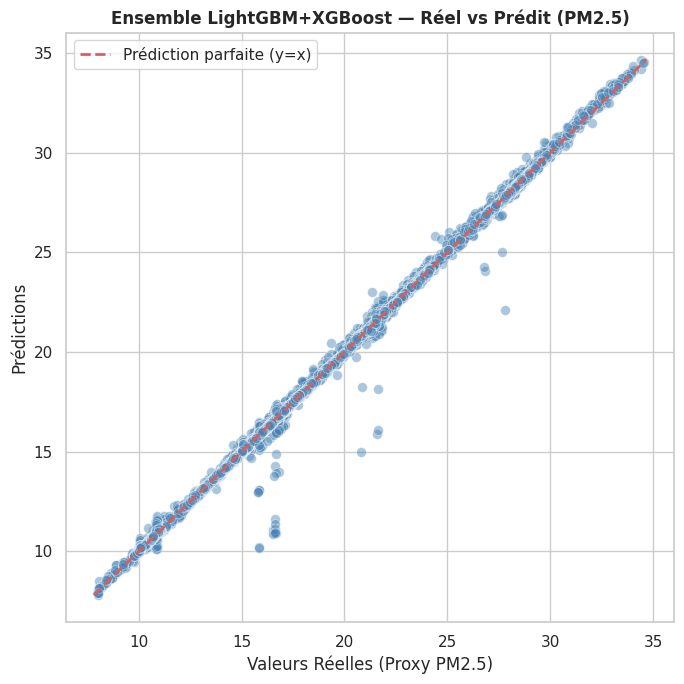

In [14]:
print('Entraînement du modèle Ensemble (LightGBM + XGBoost) — PM2.5...')

X_all, y_all = prepare_data('pm25_proxy')
X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(
    X_all, y_all, test_size=0.2, random_state=SEED, shuffle=False
)

best_lgb_e = lgb.LGBMRegressor(
    n_estimators=300, learning_rate=0.05, num_leaves=63,
    feature_fraction=0.8, random_state=SEED, verbosity=-1)
best_xgb_e = xgb.XGBRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=7,
    subsample=0.8, tree_method='hist', random_state=SEED, verbosity=0)

ensemble_pm25 = VotingRegressor(estimators=[('lgb', best_lgb_e), ('xgb', best_xgb_e)])
ensemble_pm25.fit(X_train_e, y_train_e)

y_pred_e = ensemble_pm25.predict(X_test_e)
rmse_e = np.sqrt(mean_squared_error(y_test_e, y_pred_e))
r2_e   = r2_score(y_test_e, y_pred_e)
mae_e  = mean_absolute_error(y_test_e, y_pred_e)

print(f'\n Performances Ensemble (test) :')
print(f'   R²   = {r2_e:.4f}')
print(f'   RMSE = {rmse_e:.2f} µg/m³')
print(f'   MAE  = {mae_e:.2f} µg/m³')

# ── Scatter réel vs prédit ─────────────────────────────────────────────────────
plt.figure(figsize=(7, 7))
sns.scatterplot(x=y_test_e, y=y_pred_e, alpha=0.45, color='steelblue', edgecolor='w', s=50)
lim = [min(y_test_e.min(), y_pred_e.min()), max(y_test_e.max(), y_pred_e.max())]
plt.plot(lim, lim, 'r--', lw=2, label='Prédiction parfaite (y=x)')
plt.title('Ensemble LightGBM+XGBoost — Réel vs Prédit (PM2.5)', fontweight='bold')
plt.xlabel('Valeurs Réelles (Proxy PM2.5)'); plt.ylabel('Prédictions')
plt.legend(); plt.tight_layout()
plt.savefig('plots/scatter_ensemble_pm25.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 11. Analyse SHAP — Interprétabilité du Modèle PM2.5

> Pour un outil d'aide à la décision sanitaire, **prédire ne suffit pas : il faut expliquer**.  
> SHAP décompose chaque prédiction en contributions individuelles par variable.
>
> **Lecture du graphique :**  
> - **Couleur**: Un point rouge indique une valeur élevée de la variable (ex: forte chaleur). Un point bleu indique une valeur basse (ex: vent faible).
> - **Axe X**: Si les points rouges s'étalent vers la droite, cela signifie que cette variable augmente fortement la pollution de l'air.


Calcul des valeurs SHAP (composant LightGBM)...


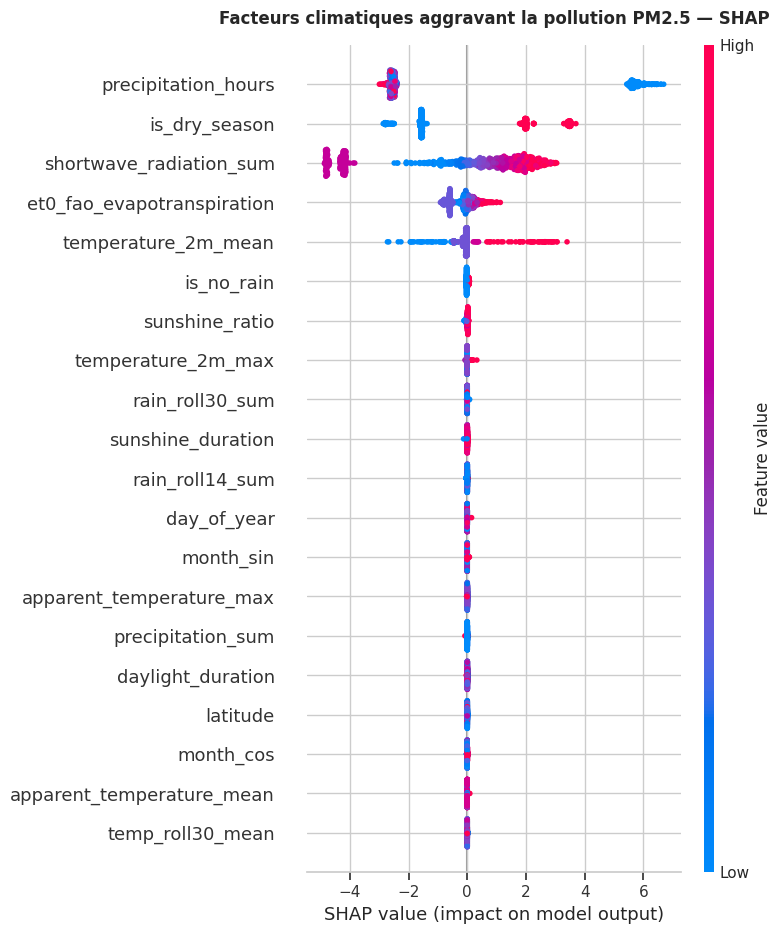

In [15]:
print('Calcul des valeurs SHAP (composant LightGBM)...')

df_ml_shap = df.copy()

cols_to_fix = FEATURES + ['pm25_proxy']
for col in cols_to_fix:
    if col in df_ml_shap.columns:
        median_val = df_ml_shap[col].median()
        df_ml_shap[col] = df_ml_shap[col].fillna(median_val)

X_shap_df = df_ml_shap[FEATURES]
y_shap = df_ml_shap['pm25_proxy']

sample_size = min(1000, len(X_shap_df))
sample_shap = X_shap_df.sample(sample_size, random_state=SEED)

lgb_shap = lgb.LGBMRegressor(n_estimators=200, learning_rate=0.1, random_state=SEED, verbosity=-1)
lgb_shap.fit(X_shap_df, y_shap)

explainer = shap.TreeExplainer(lgb_shap)
shap_values = explainer.shap_values(sample_shap)

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, sample_shap, show=False)
plt.title('Facteurs climatiques aggravant la pollution PM2.5 — SHAP', fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('plots/shap_pm25.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 12.  Sauvegarde des Modèles

> Tous les meilleurs modèles (un par cible) sont sauvegardés au format `.joblib`.  
> Le modèle Ensemble PM2.5 est le modèle de production principal pour l'API FastAPI.


In [16]:
# Mapping city → code
city_mapping   = dict(zip(df['city'], df['city_enc']))
region_mapping = dict(zip(df['region'], df['region_enc']))

# Modèle de production principal : Ensemble PM2.5
joblib.dump({
    'model'          : ensemble_pm25,
    'features'       : FEATURES,
    'city_mapping'   : city_mapping,
    'region_mapping' : region_mapping,
    'target'         : 'pm25_proxy',
    'description'    : 'Ensemble LightGBM+XGBoost — PM2.5 Proxy (µg/m³)',
    'aqi_tranches'   : AQI_TRANCHES,
}, 'models/airguard_pm25_ensemble.joblib')
print('Sauvegardé : models/airguard_pm25_ensemble.joblib')

# Meilleurs modèles par cible
models_to_save = {
    'heat_index'       : (best_model_heat,     best_name_heat,     'Heat Index (°C) — Rothfusz'),
    'deficit_eau_cumule': (best_model_water,    best_name_water,    'Déficit eau cumulé 30j (mm)'),
    'risque_inondation': (best_model_flood,     best_name_flood,    'Risque inondation [0-10]'),
    'chaleur_extreme'  : (best_model_heat_ext,  best_name_heat_ext, 'Chaleur extrême [0-10]'),
}

for target_name, (model, model_name, description) in models_to_save.items():
    path = f'models/airguard_{target_name}.joblib'
    joblib.dump({
        'model'          : model,
        'model_name'     : model_name,
        'features'       : FEATURES,
        'city_mapping'   : city_mapping,
        'region_mapping' : region_mapping,
        'target'         : target_name,
        'description'    : description,
    }, path)
    print(f'Sauvegardé : {path}  ({model_name})')

print('\n Tous les modèles sont sauvegardés dans le dossier models/')


Sauvegardé : models/airguard_pm25_ensemble.joblib
Sauvegardé : models/airguard_heat_index.joblib  (Random Forest)
Sauvegardé : models/airguard_deficit_eau_cumule.joblib  (MLP)
Sauvegardé : models/airguard_risque_inondation.joblib  (XGBoost)
Sauvegardé : models/airguard_chaleur_extreme.joblib  (LightGBM)

 Tous les modèles sont sauvegardés dans le dossier models/



 MEILLEUR MODÈLE PAR CIBLE
            Cible        Modèle  R² (moy)  MAE (moy)  MAE (std)  RMSE (moy)
      PM2.5 Proxy      LightGBM    0.9932     0.1562     0.1376      0.4056
       Heat Index Random Forest    0.9580     0.6485     1.2653      2.1471
  Stress Hydrique           MLP    0.8392    22.0116     9.6983     31.7148
Risque Inondation       XGBoost    0.9801     0.0149     0.0065      0.0407
  Chaleur Extrême      LightGBM    0.9874     0.0350     0.0351      0.0824


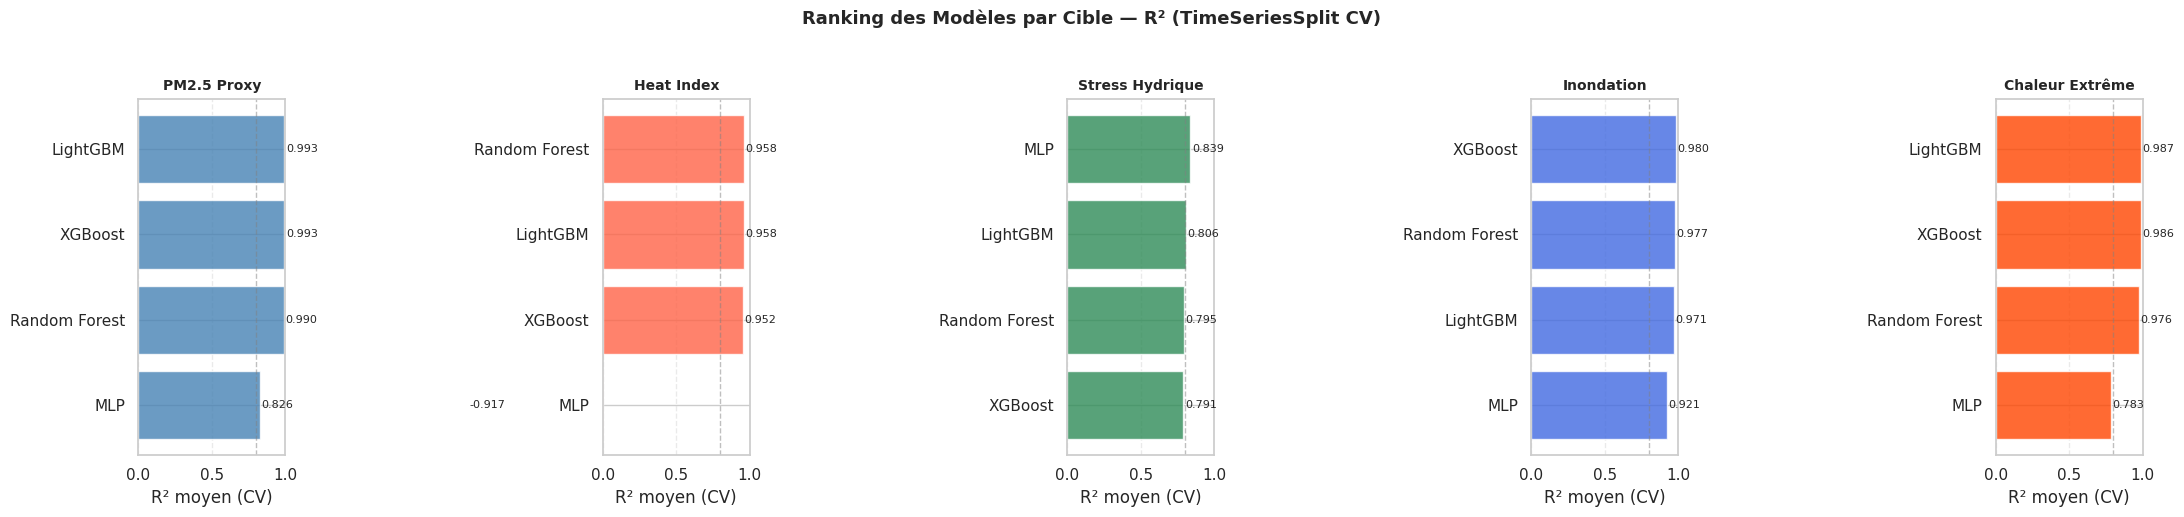

In [17]:
# Tableau global
def best_row(ranking, target_label):
    row = ranking.iloc[0].copy()
    row['Cible'] = target_label
    return row

summary = pd.DataFrame([
    best_row(ranking_pm25,     'PM2.5 Proxy'),
    best_row(ranking_heat,     'Heat Index'),
    best_row(ranking_water,    'Stress Hydrique'),
    best_row(ranking_flood,    'Risque Inondation'),
    best_row(ranking_heat_ext, 'Chaleur Extrême'),
])[['Cible', 'Modèle', 'R² (moy)', 'MAE (moy)', 'MAE (std)', 'RMSE (moy)']]

print('\n MEILLEUR MODÈLE PAR CIBLE')
print('='*80)
print(summary.to_string(index=False))

rankings_all = [
    ('PM2.5 Proxy',    ranking_pm25,     'steelblue'),
    ('Heat Index',     ranking_heat,     'tomato'),
    ('Stress Hydrique',ranking_water,    'seagreen'),
    ('Inondation',     ranking_flood,    'royalblue'),
    ('Chaleur Extrême',ranking_heat_ext, 'orangered'),
]

fig, axes = plt.subplots(1, 5, figsize=(22, 5), sharey=False)
for ax, (label, ranking, color) in zip(axes, rankings_all):
    r = ranking.sort_values('R² (moy)', ascending=True)
    bars = ax.barh(r['Modèle'], r['R² (moy)'], color=color, alpha=0.8, edgecolor='white')
    ax.set_title(label, fontweight='bold', fontsize=10)
    ax.set_xlabel('R² moyen (CV)'); ax.set_xlim(0, 1)
    ax.axvline(0.8, color='gray', lw=1, ls='--', alpha=0.5)
    for bar, val in zip(bars, r['R² (moy)']):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=8)
    ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.suptitle('Ranking des Modèles par Cible — R² (TimeSeriesSplit CV)',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('plots/ranking_final_toutes_cibles.png', dpi=150, bbox_inches='tight')
plt.show()

